# Strategic Player Valuation and Performance Forecasting in Franchise Cricket (IPL)

**Objective:** To diagnose the Indian Premier League (IPL) financial ecosystem and identify actionable market inefficiencies by merging 17 years of on-field performance metrics, franchise financial records, and macroeconomic factors.

This notebook contains the core Exploratory Data Analysis (EDA) and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set professional visualization style
sns.set_theme(style="whitegrid", context="talk")

## 1. Data Import
Loading the pre-cleaned and standardized datasets (Performance, Player Finances, and Macroeconomics).

In [2]:
# Load the cleaned datasets
df_ball = pd.read_csv("IPL_BallByBall_Cleaned_V2.csv", low_memory=False)
df_players = pd.read_csv("cleaned_ipl_player_finances.csv")
df_econ = pd.read_csv("cleaned_macroeconomic_data.csv")

# Create a full range of years for chronological plotting (to maintain visual gaps for missing data)
min_year = int(df_ball['season'].min())
max_year = int(df_ball['season'].max())
full_years_range = list(range(min_year, max_year + 1))

print("Data loaded successfully!")

Data loaded successfully!


## 2. Financial Landscape: Salary & Valuation
Analyzing the 2024 IPL auction pool to identify salary distributions and how the market values specific player roles.

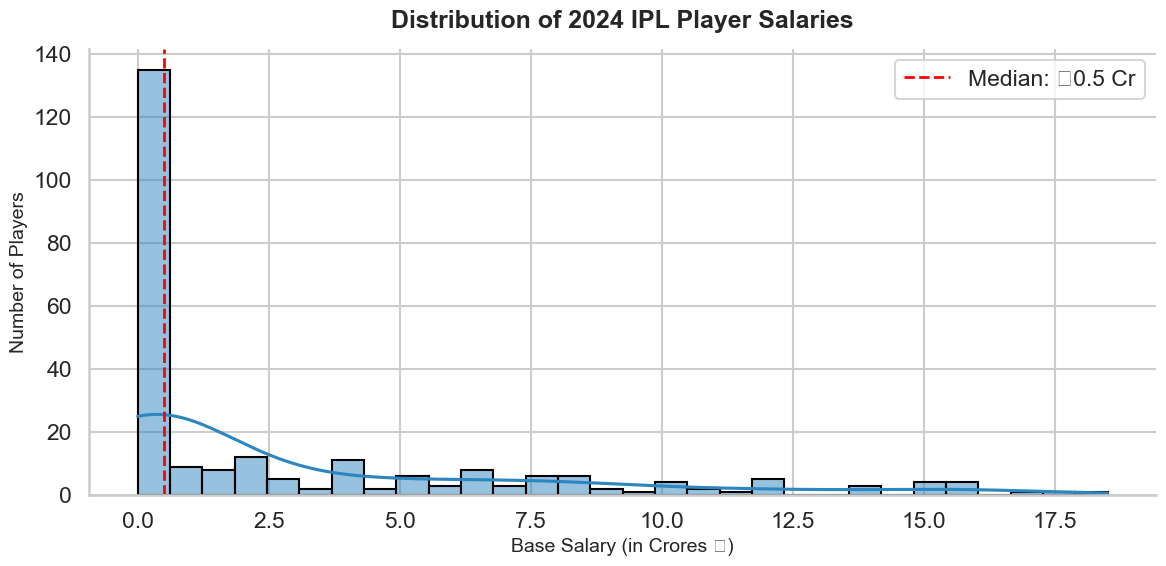

--- 2024 Salary Summary Statistics ---
Total Players: 245
Average (Mean) Salary: ₹30,182,828
Median Salary: ₹5,000,000
Maximum Salary: ₹185,000,000


In [3]:
# Visualization 1: Salary Distribution
plt.figure(figsize=(12, 6))

# Plot histogram (converting INR to Crores for readability)
ax = sns.histplot(df_players['base_salary_inr'] / 10000000, 
                  bins=30, kde=True, color="#2E86C1", edgecolor="black")

plt.title("Distribution of 2024 IPL Player Salaries", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Base Salary (in Crores ₹)", fontsize=14)
plt.ylabel("Number of Players", fontsize=14)

# Add a vertical line for the Median salary
median_salary = (df_players['base_salary_inr'].median()) / 10000000
plt.axvline(median_salary, color='red', linestyle='--', linewidth=2, label=f'Median: ₹{median_salary:.1f} Cr')
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

# Print Summary Statistics
print("--- 2024 Salary Summary Statistics ---")
print(f"Total Players: {len(df_players)}")
print(f"Average (Mean) Salary: ₹{df_players['base_salary_inr'].mean():,.0f}")
print(f"Median Salary: ₹{df_players['base_salary_inr'].median():,.0f}")
print(f"Maximum Salary: ₹{df_players['base_salary_inr'].max():,.0f}")

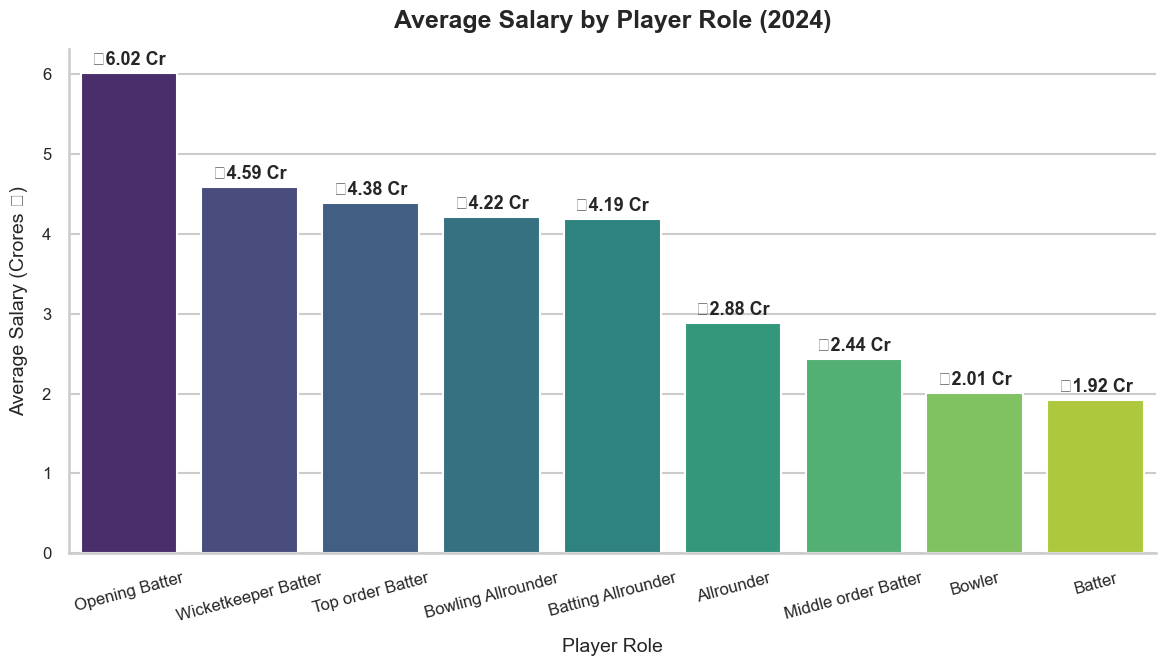

In [4]:
# Visualization 2: Average Salary by Player Role
# Filter out unwanted categories
df_filtered = df_players[~df_players['player_role'].isin(['Not Available', 'Wicketkeeper'])]

plt.figure(figsize=(12, 7))

# Calculate average salary per role in Crores
role_salary = df_filtered.groupby('player_role')['base_salary_inr'].mean() / 10000000
role_salary = role_salary.sort_values(ascending=False)

# Draw the bar chart
ax = sns.barplot(x=role_salary.index, y=role_salary.values, hue=role_salary.index, palette="viridis", legend=False)

plt.title("Average Salary by Player Role (2024)", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Player Role", fontsize=14, labelpad=10)
plt.ylabel("Average Salary (Crores ₹)", fontsize=14, labelpad=10)

plt.xticks(rotation=15, fontsize=12) 
plt.yticks(fontsize=12)
sns.despine()

# Add exact numbers on top of bars
for i in ax.containers:
    ax.bar_label(i, fmt='₹%.2f Cr', padding=3, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Tactical Evolution on the Field (2008 - 2024)
Tracking how team scoring, risk-taking, and situational aggressiveness have evolved over the 17-year history of the league.

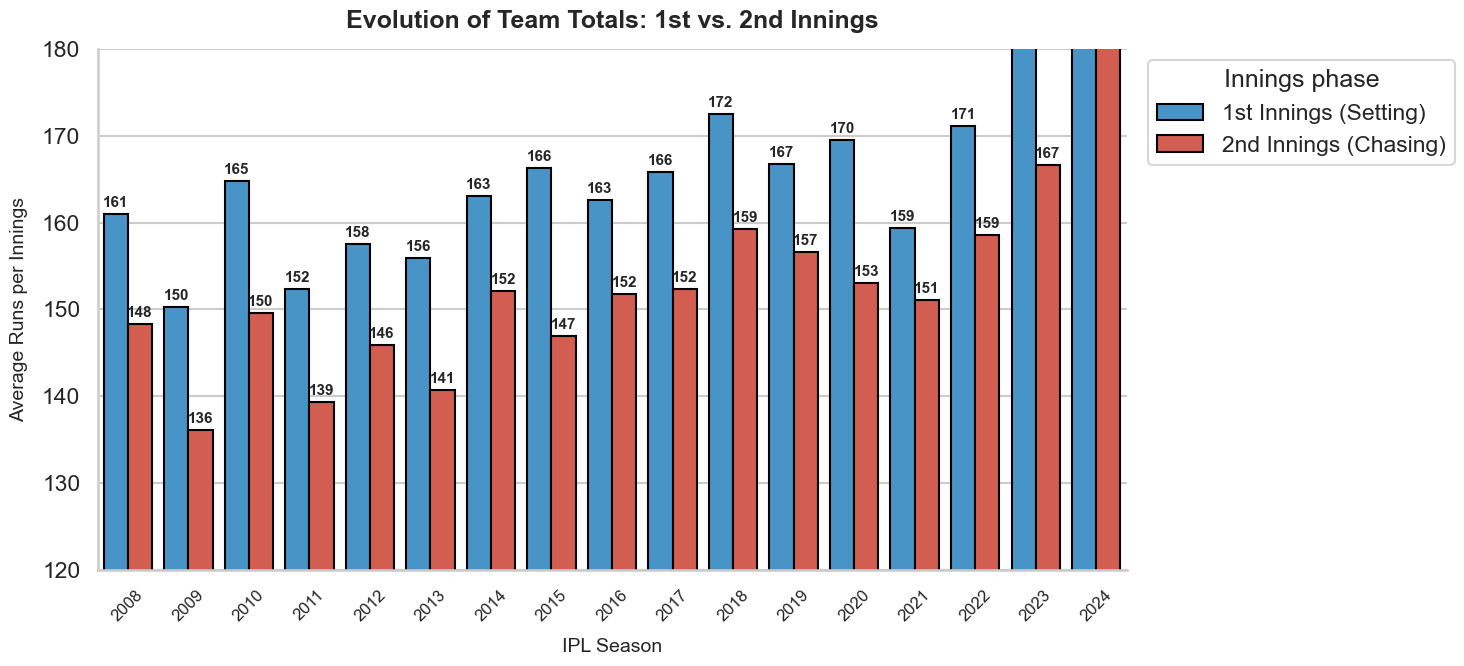

In [5]:
# Visualization 3: Evolution of Team Totals (1st vs. 2nd Innings)
df_ball['total_team_runs'] = df_ball['runs_scored'] + df_ball['extras']
innings_totals = df_ball.groupby(['season', 'match_id', 'innings_no'])['total_team_runs'].sum().reset_index()

# Keep only 1st and 2nd innings
innings_totals = innings_totals[innings_totals['innings_no'].isin([1, 2])]

# Calculate Average Innings Score
avg_score_split = innings_totals.groupby(['season', 'innings_no'])['total_team_runs'].mean().reset_index()
avg_score_split['innings_no'] = avg_score_split['innings_no'].map({1: '1st Innings (Setting)', 2: '2nd Innings (Chasing)'})

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=avg_score_split,
    x='season',
    y='total_team_runs',
    hue='innings_no',
    order=full_years_range,
    palette=['#3498DB', '#E74C3C'],
    edgecolor="black"
)

plt.title("Evolution of Team Totals: 1st vs. 2nd Innings", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("IPL Season", fontsize=14, labelpad=10)
plt.ylabel("Average Runs per Innings", fontsize=14, labelpad=10)
plt.ylim(120, 180)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Innings phase", bbox_to_anchor=(1.01, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

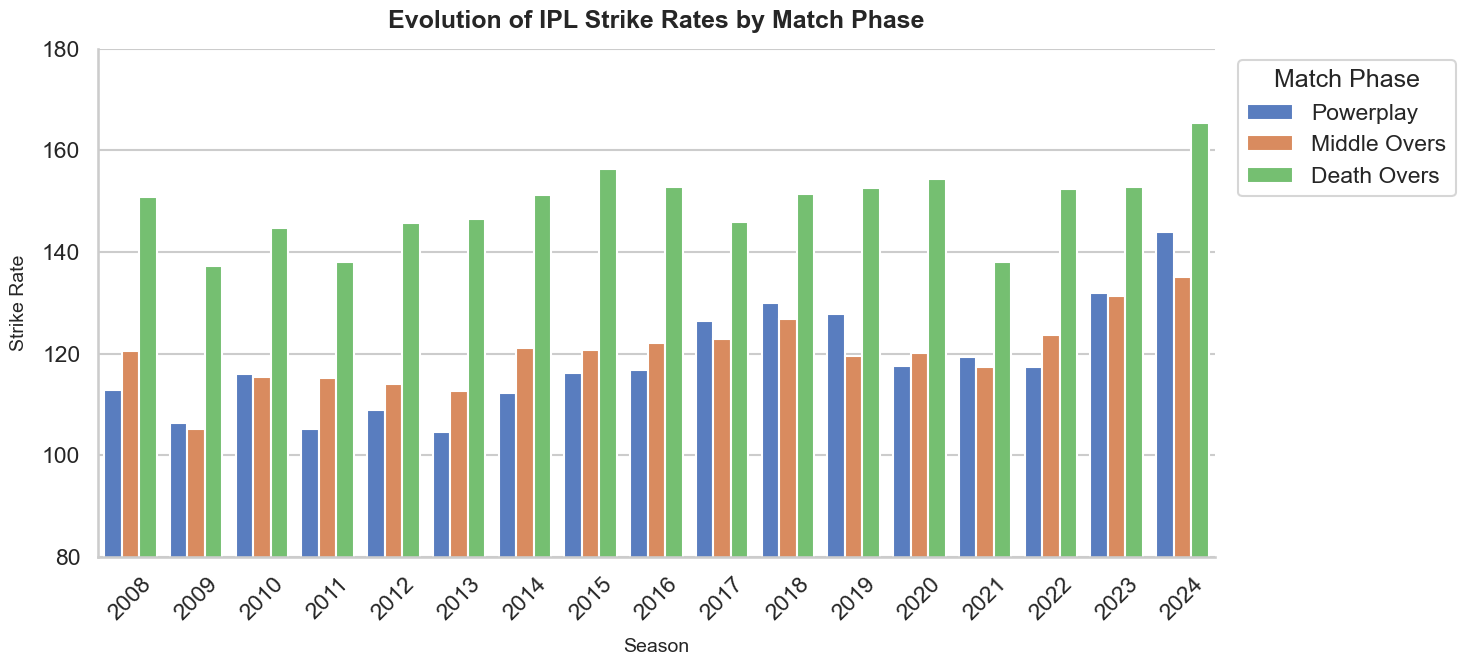

In [6]:
# Visualization 4: Strike Rate by Match Phase
phase_stats = df_ball.groupby(['season', 'match_phase']).agg(
    total_runs=('runs_scored', 'sum'),
    total_balls=('ball_no', 'count')
).reset_index()

phase_stats['strike_rate'] = (phase_stats['total_runs'] / phase_stats['total_balls']) * 100

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_stats['match_phase'] = pd.Categorical(phase_stats['match_phase'], categories=phase_order, ordered=True)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=phase_stats, 
    x='season', 
    y='strike_rate', 
    hue='match_phase', 
    palette='muted',
    order=full_years_range
)

plt.title("Evolution of IPL Strike Rates by Match Phase", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Season", fontsize=14, labelpad=10)
plt.ylabel("Strike Rate", fontsize=14, labelpad=10)
plt.ylim(80, 180)
plt.xticks(rotation=45) 
plt.legend(title="Match Phase", bbox_to_anchor=(1.01, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

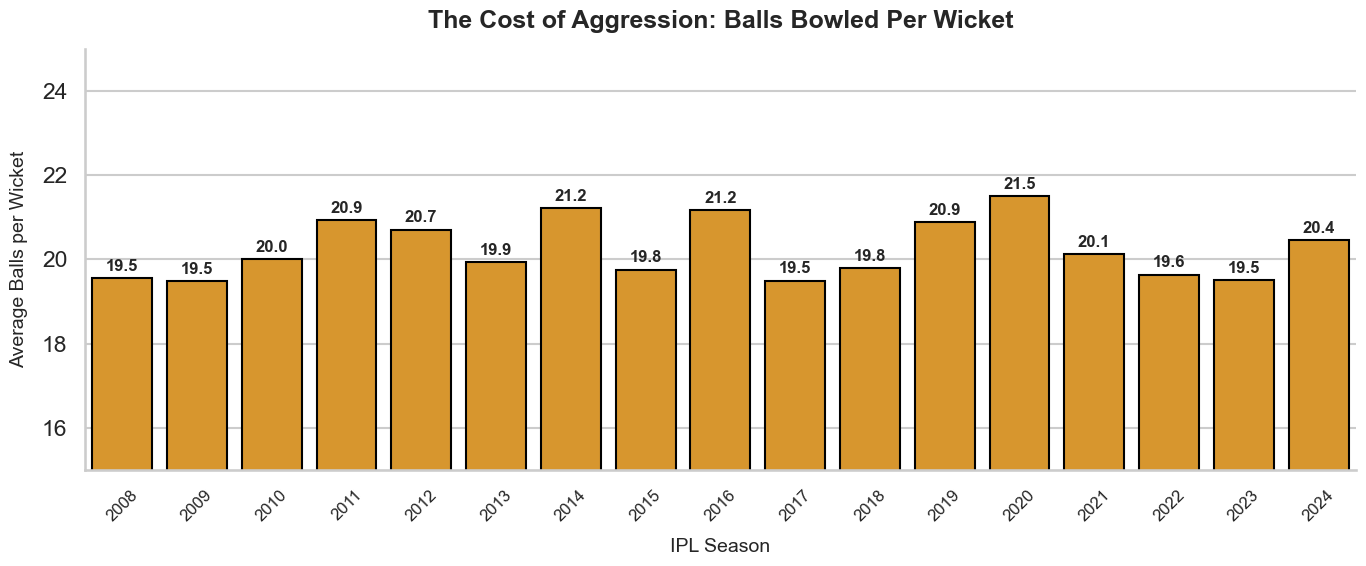

In [7]:
# Visualization 5: The Cost of Aggression (Balls per Wicket)
wicket_stats = df_ball.groupby('season').agg(
    total_wickets=('wicket_confirmation', 'sum'),
    total_balls=('ball_no', 'count')
).reset_index()

wicket_stats['balls_per_wicket'] = wicket_stats['total_balls'] / wicket_stats['total_wickets']

# Reindex to preserve timeline gaps
wicket_stats = wicket_stats.set_index('season').reindex(full_years_range).reset_index()

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=wicket_stats, 
    x='season', 
    y='balls_per_wicket', 
    color="#F39C12", 
    edgecolor="black"
)

plt.title("The Cost of Aggression: Balls Bowled Per Wicket", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("IPL Season", fontsize=14, labelpad=10)
plt.ylabel("Average Balls per Wicket", fontsize=14, labelpad=10)
plt.ylim(15, 25) 
plt.xticks(rotation=45, fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

## 4. Macroeconomic Impact: The True Cost of a Run
Merging performance data with Consumer Price Index (CPI) multipliers to determine if skyrocketing auction prices are driven by an actual increase in player value, or simply natural currency expansion.

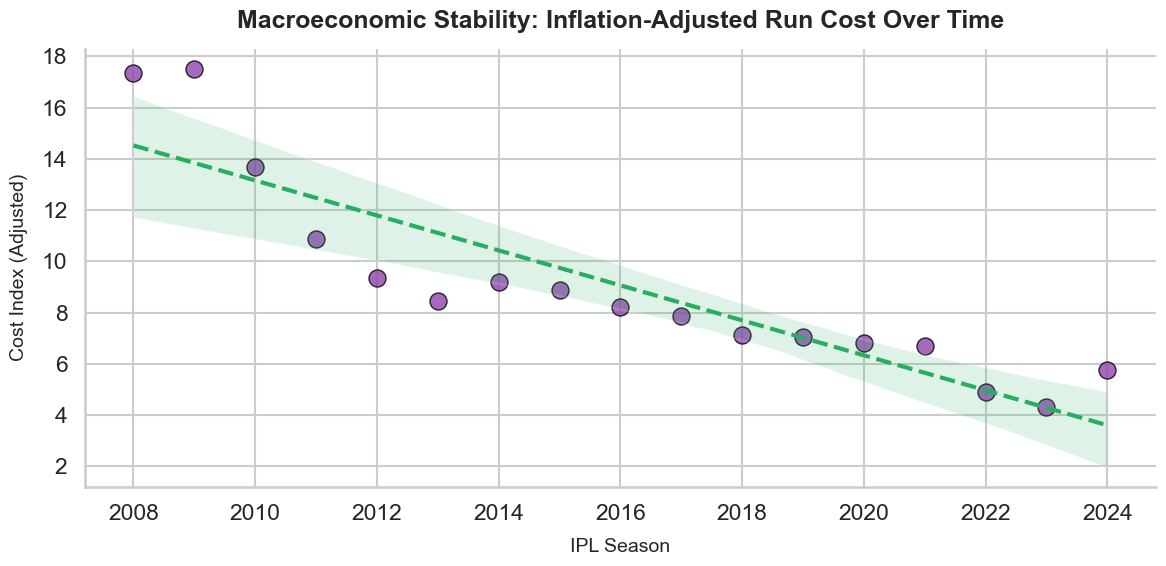

Correlation Coefficient: -0.90 (Strong Negetive)


In [8]:
# Visualization 6: Inflation-Adjusted Cost Index
yearly_runs = df_ball.groupby('season')['runs_scored'].sum().reset_index()

# Merge total runs with economic inflation data
df_merged = pd.merge(yearly_runs, df_econ, on='season', how='inner')

# Calculate the inflation-adjusted cost index
df_merged['inflation_adjusted_cost_index'] = (100000 / df_merged['runs_scored']) * df_merged['inflation_multiplier']

plt.figure(figsize=(12, 6))

ax = sns.regplot(
    data=df_merged, 
    x='season', 
    y='inflation_adjusted_cost_index',
    scatter_kws={"s": 150, "color": "#8E44AD", "edgecolor": "black"},
    line_kws={"color": "#27AE60", "linewidth": 3, "linestyle": "--"}
)

plt.title("Macroeconomic Stability: Inflation-Adjusted Run Cost Over Time", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("IPL Season", fontsize=14, labelpad=10)
plt.ylabel("Cost Index (Adjusted)", fontsize=14, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

# Print Correlation
correlation = df_merged['season'].corr(df_merged['inflation_adjusted_cost_index'])
print(f"Correlation Coefficient: {correlation:.2f} (Strong Negetive)")